# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Jazmin Correa Ortega

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jazmincorrea
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:04<00:00, 97.6MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [4]:
# Your exploration here

for class_name in class_names_fire:
    class_path = os.path.join(data_dir_fire, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

fire_images : 755
non_fire_images : 244


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

I noticed that the dataset is not very balanced as one class has many more images than the other. I think this may make the model have a hard time performing well.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [5]:
# Preprocess the data here

def preprocess_fire(image, label):
    return preprocess_input(image), label

train_ds_fire = train_raw_fire.map(preprocess_fire)
val_ds_fire = val_raw_fire.map(preprocess_fire)
test_ds_fire = test_raw_fire.map(preprocess_fire)

In [6]:
# Build your model here

base_model_fire = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base
base_model_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model_fire(inputs, training=False)
x = GlobalAveragePooling2D()(x)

outputs = Dense(1, activation="sigmoid")(x)

model_fire = Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# Compile your model here

model_fire.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

## 1D — Train and Evaluate

In [8]:
# Train your model here

history_fire = model_fire.fit(
    train_ds_fire,
    validation_data=val_ds_fire,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8200 - loss: 0.3509 - val_accuracy: 0.9281 - val_loss: 0.2419
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9586 - loss: 0.1556 - val_accuracy: 0.9496 - val_loss: 0.1457
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9714 - loss: 0.1069 - val_accuracy: 0.9568 - val_loss: 0.1292
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9786 - loss: 0.0865 - val_accuracy: 0.9784 - val_loss: 0.0930
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9829 - loss: 0.0741 - val_accuracy: 0.9784 - val_loss: 0.0714


In [9]:
# Report validation and test accuracy here

fire_val_loss, fire_val_acc = model_fire.evaluate(val_ds_fire)
fire_test_loss, fire_test_acc = model_fire.evaluate(test_ds_fire)

print("Validation Accuracy:", fire_val_acc)
print("Test Accuracy:", fire_test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 959ms/step - accuracy: 0.9568 - loss: 0.1068
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9688 - loss: 0.0918
Validation Accuracy: 0.9568345546722412
Test Accuracy: 0.96875


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

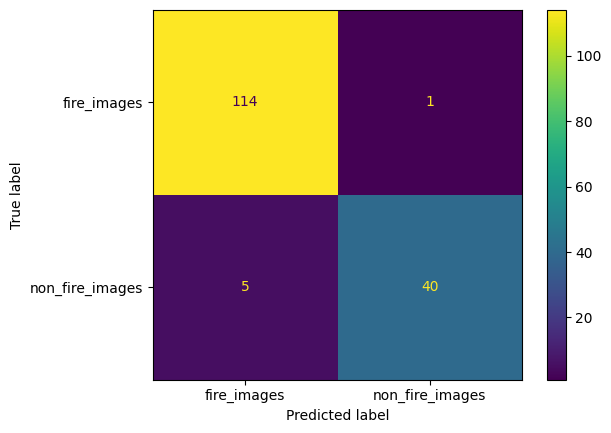

In [10]:
# Build your confusion matrix here

y_true_fire = []
y_pred_fire = []

for images, labels in test_ds_fire:
    predictions = model_fire.predict(images, verbose=0)

    predicted_labels = (predictions > 0.5).astype("int32").flatten()

    y_true_fire.extend(labels.numpy())
    y_pred_fire.extend(predicted_labels)

cm_fire = confusion_matrix(y_true_fire, y_pred_fire)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_fire,
    display_labels=class_names_fire
)

disp.plot()
plt.show()

*Your answer:*
I would say that a false negative is more costly because it would mean that the model is missing a fire which could then be dangerous. I think what I could do is change the threshold to a number below 0.5 so the model is a bit more likely to detect a fire.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [11]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [12]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [13]:
# Preprocess the data here

def preprocess_sat(image, label):
    return preprocess_input(image), label

train_ds_sat = train_raw_sat.map(preprocess_sat)
val_ds_sat = val_raw_sat.map(preprocess_sat)
test_ds_sat = test_raw_sat.map(preprocess_sat)

In [14]:
# Build your model here

base_model_sat = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)

outputs = Dense(
    len(class_names_sat),
    activation="softmax"
)(x)

model_sat = Model(inputs, outputs)

In [15]:
# Compile your model here

model_sat.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

## 2C — Train and Evaluate

In [16]:
# Train your model here

history_sat = model_sat.fit(
    train_ds_sat,
    validation_data=val_ds_sat,
    epochs=5
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 978s 2s/step - accuracy: 0.8747 - loss: 0.3853 - val_accuracy: 0.9311 - val_loss: 0.2166
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 976s 2s/step - accuracy: 0.9339 - loss: 0.1970 - val_accuracy: 0.9423 - val_loss: 0.1893
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 972s 2s/step - accuracy: 0.9453 - loss: 0.1607 - val_accuracy: 0.9398 - val_loss: 0.1840
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 951s 2s/step - accuracy: 0.9533 - loss: 0.1400 - val_accuracy: 0.9408 - val_loss: 0.1779
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 990s 2s/step - accuracy: 0.9610 - loss: 0.1228 - val_accuracy: 0.9390 - val_loss: 0.1764


In [ ]:
# Report validation and test accuracy here



## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

In [ ]:
# Build your confusion matrix here



*Your answer:*




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | | |
| Test Accuracy | | |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.